In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN

In [2]:
df = pd.read_csv('CC GENERAL.csv')

In [3]:
numerical_features = df.select_dtypes(include=[np.number]).columns
df[numerical_features] = df[numerical_features].fillna(df[numerical_features].mean())
df.isnull().sum()

CUST_ID                             0
BALANCE                             0
BALANCE_FREQUENCY                   0
PURCHASES                           0
ONEOFF_PURCHASES                    0
INSTALLMENTS_PURCHASES              0
CASH_ADVANCE                        0
PURCHASES_FREQUENCY                 0
ONEOFF_PURCHASES_FREQUENCY          0
PURCHASES_INSTALLMENTS_FREQUENCY    0
CASH_ADVANCE_FREQUENCY              0
CASH_ADVANCE_TRX                    0
PURCHASES_TRX                       0
CREDIT_LIMIT                        0
PAYMENTS                            0
MINIMUM_PAYMENTS                    0
PRC_FULL_PAYMENT                    0
TENURE                              0
dtype: int64

In [4]:
x = df[numerical_features]

In [5]:
scaler = StandardScaler()
sc_x = scaler.fit_transform(x)

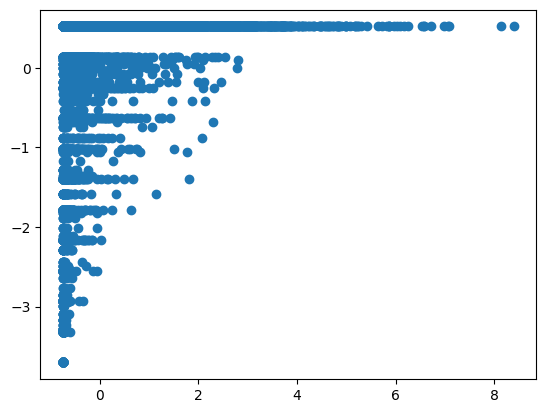

In [6]:
plt.scatter(sc_x[:,0],sc_x[:,1])

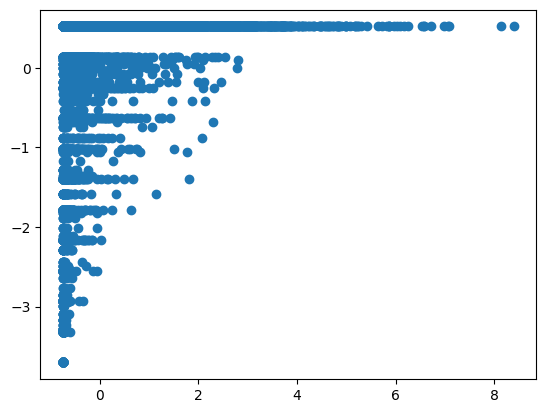

In [7]:
from sklearn.decomposition import PCA
pca_for_dbscan = PCA(n_components=10)
sc_x_reduced = pca_for_dbscan.fit_transform(sc_x)

plt.scatter(sc_x[:,0],sc_x[:,1])

In [9]:
from sklearn.metrics import silhouette_score
for eps in [1, 2, 3, 4, 5, 6, 7, 8]:
    db = DBSCAN(eps=eps, min_samples=5)
    cluster = db.fit_predict(sc_x_reduced)
    
    unique_clusters = set(cluster)
    cluster_counts = pd.Series(cluster).value_counts().to_dict()
    print(f"eps = {eps}, unique clusters = {len(unique_clusters)}, counts: {cluster_counts}")
    
    # ✅ Only calculate silhouette score if we have at least 2 non-noise clusters
    non_noise_clusters = set(cluster) - {-1}
    if len(non_noise_clusters) >= 2:
        score = silhouette_score(sc_x_reduced[cluster != -1], pd.Series(cluster)[cluster != -1])
        print(f"Silhouette Score (without noise): {score}\n")
    else:
        print("Silhouette Score: Not applicable (only 1 cluster or all noise)\n")


eps = 1, unique clusters = 16, counts: {0: 6887, -1: 1975, 5: 20, 6: 9, 10: 7, 12: 6, 13: 6, 2: 5, 4: 5, 3: 5, 11: 5, 8: 4, 1: 4, 14: 4, 7: 4, 9: 4}
Silhouette Score (without noise): -0.06114063861438245

eps = 2, unique clusters = 2, counts: {0: 8609, -1: 341}
Silhouette Score: Not applicable (only 1 cluster or all noise)

eps = 3, unique clusters = 2, counts: {0: 8832, -1: 118}
Silhouette Score: Not applicable (only 1 cluster or all noise)

eps = 4, unique clusters = 2, counts: {0: 8888, -1: 62}
Silhouette Score: Not applicable (only 1 cluster or all noise)

eps = 5, unique clusters = 2, counts: {0: 8909, -1: 41}
Silhouette Score: Not applicable (only 1 cluster or all noise)

eps = 6, unique clusters = 2, counts: {0: 8928, -1: 22}
Silhouette Score: Not applicable (only 1 cluster or all noise)

eps = 7, unique clusters = 2, counts: {0: 8934, -1: 16}
Silhouette Score: Not applicable (only 1 cluster or all noise)

eps = 8, unique clusters = 2, counts: {0: 8941, -1: 9}
Silhouette Score: 

In [33]:
db = DBSCAN(eps=2.5,min_samples=5)
cluster = db.fit_predict(sc_x_reduced)

In [34]:
df['Cluster'] = cluster

In [35]:
df['Cluster'].value_counts()

Cluster
 0    8764
-1     186
Name: count, dtype: int64

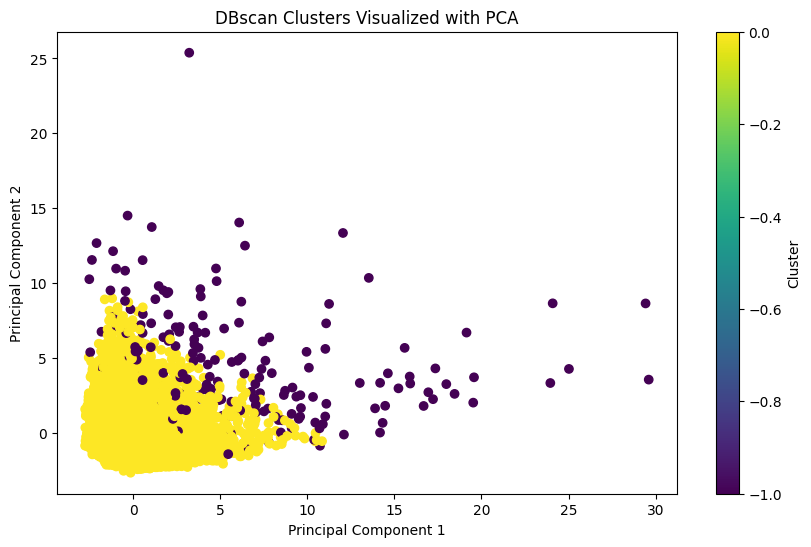

In [36]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_components = pca.fit_transform(sc_x)

# Plot the clusters
plt.figure(figsize=(10, 6))
plt.scatter(pca_components[:, 0], pca_components[:, 1], c=df['Cluster'], cmap='viridis')
plt.title('DBscan Clusters Visualized with PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar(label='Cluster')
plt.show()

In [37]:
print(df.groupby('Cluster').mean(numeric_only=True))

             BALANCE  BALANCE_FREQUENCY    PURCHASES  ONEOFF_PURCHASES  \
Cluster                                                                  
-1       5908.979383           0.954404  7846.724839       4940.129677   
 0       1472.270600           0.875634   857.963537        500.165490   

         INSTALLMENTS_PURCHASES  CASH_ADVANCE  PURCHASES_FREQUENCY  \
Cluster                                                              
-1                  2909.820968   5159.551301             0.736508   
 0                   358.036139    890.143760             0.485126   

         ONEOFF_PURCHASES_FREQUENCY  PURCHASES_INSTALLMENTS_FREQUENCY  \
Cluster                                                                 
-1                         0.449829                          0.601675   
 0                         0.197208                          0.359402   

         CASH_ADVANCE_FREQUENCY  CASH_ADVANCE_TRX  PURCHASES_TRX  \
Cluster                                                      

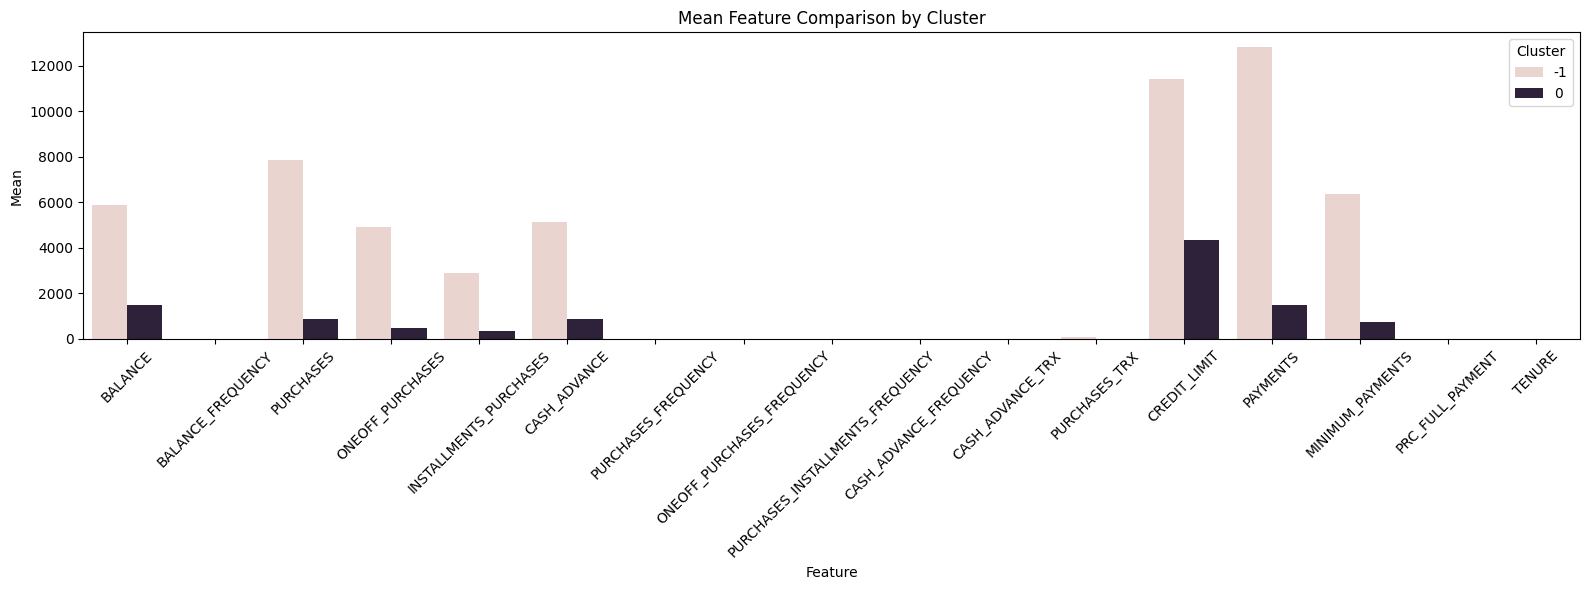

In [38]:
import seaborn as sns

# Melt the data for seaborn
cluster_means = df.groupby('Cluster').mean(numeric_only=True)
mean_df = cluster_means.reset_index().melt(id_vars='Cluster', var_name='Feature', value_name='Mean')
# melt function is used to reshape the data. It converts the DataFrame from a wide format to a long format.

plt.figure(figsize=(16, 6))
sns.barplot(data=mean_df, x='Feature', y='Mean', hue='Cluster')
plt.title('Mean Feature Comparison by Cluster')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [39]:
from sklearn.metrics import silhouette_score
score = silhouette_score(sc_x_reduced, cluster)
print(f"Silhouette Score: {score}")

Silhouette Score: 0.6366541444343812


In [40]:
from sklearn.ensemble import RandomForestClassifier

In [41]:
x = df[numerical_features]
y = df['Cluster']

In [42]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=42)

In [43]:
regressor = RandomForestClassifier()

In [44]:
parameters = {
    'n_estimators': [50, 100],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
}

In [52]:
rcv = GridSearchCV(regressor, param_grid=parameters, cv=5, scoring='accuracy')

In [53]:
rcv.fit(x_train,y_train)

,estimator,RandomForestClassifier()
,param_grid,"{'max_depth': [None, 10, ...], 'min_samples_split': [2, 5], 'n_estimators': [50, 100]}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,100


In [54]:
rcv.best_params_

{'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}

In [55]:
print(rcv.best_score_)

0.9924017342227124


In [56]:
y_pred = rcv.predict(x_test)

In [57]:
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error

In [58]:
print("R²:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))

R²: 0.5218738164832923
MAE: 0.009830205540661306
MSE: 0.009830205540661306


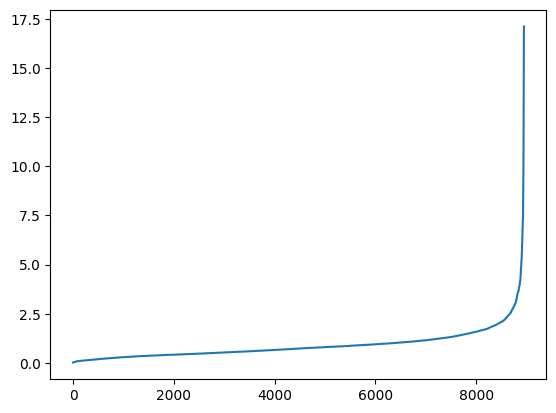

In [32]:
from sklearn.neighbors import NearestNeighbors
neigh = NearestNeighbors(n_neighbors=5)
nbrs = neigh.fit(sc_x_reduced)
distances, indices = nbrs.kneighbors(sc_x_reduced)
distances = np.sort(distances[:,4])
plt.plot(distances)